In [1]:
!pip install -q rasterio transformers albumentations accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00


In [2]:
import os
import requests
import zipfile
import glob
import random
import numpy as np
import pandas as pd
import rasterio
import torch
import cv2
import albumentations as A
from torch import nn
from torch.utils.data import Dataset
from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation,
    TrainingArguments,
    Trainer
)
import logging
import warnings

# 1. Suppress the specific rasterio/GDAL logging
# This stops the "WARNING:rasterio._env:CPLE_AppDefined..." messages
logging.getLogger("rasterio").setLevel(logging.ERROR)

# 2. Suppress standard Python warnings (optional, but cleaner)
warnings.filterwarnings("ignore")

# --- Experiment Configuration ---
class Config:
    # Experiment Identifiers
    EXPERIMENT_NAME = "segformer_b0_zenodo_burned_area"
    DATA_ROOT = "dataset"

    # Zenodo Data Sources
    DATA_URLS = [
        ("https://zenodo.org/record/6597139/files/satellite_data.csv?download=1", "satellite_data.csv"),
        ("https://zenodo.org/record/6597139/files/Satellite_burned_area_dataset_part1.zip?download=1", "Satellite_burned_area_dataset_part1.zip")
    ]

    # Data Processing
    CROP_SIZE = 512
    VALIDATION_FOLD = "purple" # Specific fold from the CSV to use for validation

    # Model Architecture
    MODEL_CHECKPOINT = "nvidia/segformer-b0-finetuned-ade-512-512"
    NUM_LABELS = 2
    ID2LABEL = {0: "Safe", 1: "Fire"}
    LABEL2ID = {"Safe": 0, "Fire": 1}

    # Training Hyperparameters
    BATCH_SIZE = 4
    LEARNING_RATE = 6e-5
    EPOCHS = 10
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # Reproducibility
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

print(f"⚙️ Configuration loaded for: {Config.EXPERIMENT_NAME}")
print(f"🔧 Device: {Config.DEVICE}")

⚙️ Configuration loaded for: segformer_b0_zenodo_burned_area
🔧 Device: cuda


In [3]:
class DataManager:
    """
    Automates downloading and extracting the Zenodo Burned Area dataset.
    """
    @staticmethod
    def _download_file(url, save_path):
        print(f"⬇️ Downloading {save_path}...")
        response = requests.get(url, stream=True)
        with open(save_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk: f.write(chunk)
        print("✅ Download complete.")

    @classmethod
    def setup_dataset(cls):
        os.makedirs(Config.DATA_ROOT, exist_ok=True)

        # 1. Download Files
        for url, filename in Config.DATA_URLS:
            file_path = os.path.join(Config.DATA_ROOT, filename)
            if not os.path.exists(file_path):
                cls._download_file(url, file_path)
            else:
                print(f"✅ Found {filename}, skipping download.")

        # 2. Extract Zip
        zip_path = os.path.join(Config.DATA_ROOT, "Satellite_burned_area_dataset_part1.zip")
        extract_path = os.path.join(Config.DATA_ROOT, "Satellite_burned_area_dataset_part1")

        # Check if already extracted (simple check for directory existence)
        if not os.path.exists(extract_path):
            print("📦 Extracting dataset (this may take a moment)...")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(Config.DATA_ROOT)
            print("✅ Extraction complete.")
        else:
            print("✅ Dataset already extracted.")

# Trigger Setup
DataManager.setup_dataset()

⬇️ Downloading dataset/satellite_data.csv...
✅ Download complete.
⬇️ Downloading dataset/Satellite_burned_area_dataset_part1.zip...
✅ Download complete.
📦 Extracting dataset (this may take a moment)...
✅ Extraction complete.


In [4]:
from rasterio.windows import Window
import itertools

class AdvancedBurnedAreaDataset(Dataset):
    """
    Robust Dataset for Zenodo Burned Area with Tiling.
    Features:
    - Dynamic Band Selection (1-band duplication or RGB extraction)
    - Grid Tiling (splits large images into fixed tiles for full coverage)
    - Robust Error Handling (skips corrupt files)
    """
    def __init__(self, csv_file, root_dir, feature_extractor, fold, split="train"):
        self.df = pd.read_csv(csv_file)
        self.root_dir = os.path.join(root_dir, "Satellite_burned_area_dataset_part1")
        self.feature_extractor = feature_extractor
        self.split = split
        self.crop_size = Config.CROP_SIZE

        # Filter by Fold
        if 'fold' in self.df.columns:
            if split == "train":
                self.df = self.df[self.df['fold'] != fold]
            else:
                self.df = self.df[self.df['fold'] == fold]

        # Validate files & Prepare Tiles
        self.tiles = []
        self._prepare_tiles()

        # Transforms
        if split == "train":
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(p=0.2),
                # Ensure tile is crop_size (handles edge tiles)
                A.PadIfNeeded(min_height=self.crop_size, min_width=self.crop_size, border_mode=0, value=0)
            ])
        else:
            # Validation: Just Pad (Tiling handles the cropping)
            self.transform = A.Compose([
                A.PadIfNeeded(min_height=self.crop_size, min_width=self.crop_size, border_mode=0, value=0)
            ])

    def _prepare_tiles(self):
        """Pre-scans images to generate a grid of tiles."""
        print(f"[{self.split.upper()}] Indexing tiles (this may take a moment)...")
        valid_count = 0

        for idx, row in self.df.iterrows():
            folder_path = os.path.join(self.root_dir, row['folder'])
            if not os.path.exists(folder_path):
                continue

            # Find image file to get dimensions
            try:
                all_files = os.listdir(folder_path)
                img_files = [f for f in all_files if f.endswith(('.tif', '.tiff')) and 'mask' not in f.lower()]
                if not img_files: continue

                # Prioritize Sentinel-2
                s2_files = [f for f in img_files if 'sentinel2' in f.lower()]
                target_file = s2_files[0] if s2_files else img_files[0]

                # Open header to get size
                with rasterio.open(os.path.join(folder_path, target_file)) as src:
                    W, H = src.width, src.height

                # Generate Grid
                # Stride = crop_size means non-overlapping tiles
                stride = self.crop_size

                for y in range(0, H, stride):
                    for x in range(0, W, stride):
                        # Calculate window size (handle edges)
                        w = min(self.crop_size, W - x)
                        h = min(self.crop_size, H - y)

                        self.tiles.append({
                            'df_idx': idx,
                            'col_off': x,
                            'row_off': y,
                            'width': w,
                            'height': h
                        })
                valid_count += 1
            except Exception as e:
                continue

        print(f"[{self.split.upper()}] Processed {valid_count} scenes into {len(self.tiles)} tiles.")

    def __len__(self):
        return len(self.tiles)

    def _load_image_bands(self, img_path, window):
        """Handle 1-band vs Multi-band logic with Window Reading."""
        with rasterio.open(img_path) as src:
            if src.count == 1:
                # Case 1: Single band -> Duplicate
                band = src.read(1, window=window)
                image = np.stack([band, band, band], axis=0)
            else:
                # Case 2: Multi-band -> Try RGB
                bands = [4, 3, 2] if src.count >= 4 else [1, 2, 3]
                if max(bands) > src.count:
                    bands = [1, 2, 3][:src.count]

                image = src.read(bands, window=window)

                # Pad channels if needed
                if image.shape[0] < 3:
                    pad = np.zeros((3 - image.shape[0], image.shape[1], image.shape[2]), dtype=image.dtype)
                    image = np.concatenate([image, pad], axis=0)

            # Normalize
            image = np.moveaxis(image, 0, -1)
            if image.max() > 0:
                image = (image / image.max() * 255).astype(np.uint8)
            else:
                image = image.astype(np.uint8)
            return image

    def __getitem__(self, idx):
        # Retry logic not strictly needed with pre-calculated tiles,
        # but good for robustness against read errors
        try:
            tile_info = self.tiles[idx]
            row = self.df.iloc[tile_info['df_idx']]
            folder_path = os.path.join(self.root_dir, row['folder'])

            # Re-find files (safe way)
            all_files = os.listdir(folder_path)
            mask_files = [f for f in all_files if 'mask' in f.lower() and f.endswith(('.tif', '.tiff'))]
            img_files = [f for f in all_files if f not in mask_files and f.endswith(('.tif', '.tiff'))]

            # Filter for Sentinel-2 if present
            s2_files = [f for f in img_files if 'sentinel2' in f.lower()]
            if s2_files:
                img_files = s2_files
            img_files.sort()

            # Define Window
            window = Window(tile_info['col_off'], tile_info['row_off'],
                            tile_info['width'], tile_info['height'])

            # Load Data Window
            image = self._load_image_bands(os.path.join(folder_path, img_files[-1]), window)

            with rasterio.open(os.path.join(folder_path, mask_files[0])) as src:
                mask = src.read(1, window=window)
                mask[mask > 0] = 1
                mask = mask.astype(np.uint8)

            # Apply Albumentations (Handles Padding for edge tiles)
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

            # Encode
            encoded = self.feature_extractor(
                images=image,
                segmentation_maps=mask,
                return_tensors="pt",
                do_resize=False,
                do_rescale=False
            )

            return {k: v.squeeze() for k, v in encoded.items()}

        except Exception as e:
            # Fallback to a random other tile if read fails
            new_idx = random.randint(0, len(self.tiles)-1)
            return self.__getitem__(new_idx)

In [5]:
class ComboLoss(nn.Module):
    def __init__(self, smooth=1):
        super(ComboLoss, self).__init__()
        self.smooth = smooth
        self.ce = nn.CrossEntropyLoss(ignore_index=255)

    def forward(self, inputs, targets):
        # 1. Cross Entropy
        ce_loss = self.ce(inputs, targets)

        # 2. Dice Loss
        probs = torch.softmax(inputs, dim=1)
        fire_probs = probs[:, 1].contiguous().view(-1) # Class 1 = Fire
        targets_flat = targets.contiguous().view(-1)

        # Filter ignore_index (255) for Dice calc
        valid_mask = targets_flat != 255
        fire_probs = fire_probs[valid_mask]
        targets_flat = targets_flat[valid_mask]

        if len(targets_flat) == 0:
             return ce_loss

        intersection = (fire_probs * targets_flat).sum()
        dice = (2. * intersection + self.smooth) / (fire_probs.sum() + targets_flat.sum() + self.smooth)

        return 0.5 * ce_loss + 0.5 * (1 - dice)

class ComboTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.criterion = ComboLoss().to(Config.DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Upsample logits to match labels (SegFormer outputs 1/4 res)
        logits_upsampled = nn.functional.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        loss = self.criterion(logits_upsampled, labels)
        return (loss, outputs) if return_outputs else loss

In [6]:
import evaluate
import torch
import numpy as np

# 1. Initialize Processor & Model
print(f"🚀 Loading Model: {Config.MODEL_CHECKPOINT}")
processor = SegformerImageProcessor.from_pretrained(
    Config.MODEL_CHECKPOINT,
    do_reduce_labels=False,
    do_resize=False,
    do_rescale=False
)

model = SegformerForSemanticSegmentation.from_pretrained(
    Config.MODEL_CHECKPOINT,
    num_labels=Config.NUM_LABELS,
    id2label=Config.ID2LABEL,
    label2id=Config.LABEL2ID,
    ignore_mismatched_sizes=True
)

# 2. Prepare Datasets (Using your existing Dataset class)
train_ds = AdvancedBurnedAreaDataset(
    os.path.join(Config.DATA_ROOT, "satellite_data.csv"),
    Config.DATA_ROOT,
    processor,
    fold=Config.VALIDATION_FOLD,
    split="train"
)
val_ds = AdvancedBurnedAreaDataset(
    os.path.join(Config.DATA_ROOT, "satellite_data.csv"),
    Config.DATA_ROOT,
    processor,
    fold=Config.VALIDATION_FOLD,
    split="val"
)

# 3. Define Metrics (CRITICAL MISSING PIECE)
metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Convert logits to Tensor
    logits_tensor = torch.from_numpy(logits)

    # Upsample if necessary (Standard SegFormer behavior)
    if logits_tensor.shape[-2:] != labels.shape[-2:]:
        logits_tensor = torch.nn.functional.interpolate(
            logits_tensor,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    predictions = logits_tensor.argmax(dim=1).numpy()

    metrics = metric.compute(
        predictions=predictions,
        references=labels,
        num_labels=2,
        ignore_index=255,
        reduce_labels=False,
    )

    # Extract 'Fire' IoU (Class 1)
    fire_iou = metrics["per_category_iou"][1] if len(metrics["per_category_iou"]) > 1 else 0.0

    return {
        "mean_iou": metrics["mean_iou"],
        "mean_accuracy": metrics["mean_accuracy"],
        "fire_iou": fire_iou,
    }

# 4. Define Arguments
args = TrainingArguments(
    output_dir=f"./results/{Config.EXPERIMENT_NAME}",
    learning_rate=Config.LEARNING_RATE,
    num_train_epochs=Config.EPOCHS,
    per_device_train_batch_size=Config.BATCH_SIZE,
    per_device_eval_batch_size=Config.BATCH_SIZE,
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=2,
    logging_steps=50,
    fp16=(Config.DEVICE == "cuda"),
    remove_unused_columns=False,
    report_to="none"
)

# 5. Train using Standardized Trainer

trainer = ComboTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print(f"🔥 Starting training on {Config.DEVICE}...")
trainer.train()

# 6. Save
save_path = f"./models/{Config.EXPERIMENT_NAME}"
trainer.save_model(save_path)
processor.save_pretrained(save_path)
print(f"🏆 Training finished. Model saved to {save_path}")

🚀 Loading Model: nvidia/segformer-b0-finetuned-ade-512-512


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[TRAIN] Indexing tiles (this may take a moment)...
[TRAIN] Processed 15 scenes into 156 tiles.
[VAL] Indexing tiles (this may take a moment)...
[VAL] Processed 2 scenes into 78 tiles.


🔥 Starting training on cuda...


Epoch,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Fire Iou
1,No log,0.694575,0.490503,0.905483,0.088420
2,0.548800,0.576489,0.724646,0.964623,0.458741
3,0.422700,0.536004,0.812764,0.973201,0.631394
4,0.355700,0.521154,0.854903,0.957776,0.714686
5,0.355700,0.603911,0.506286,0.943390,0.088666
6,0.321200,0.540665,0.540663,0.924704,0.143369
7,0.273500,0.461439,0.828735,0.958017,0.665419
8,0.245800,0.548122,0.534888,0.937262,0.121128
9,0.253700,0.502771,0.746702,0.948815,0.501940
10,0.253700,0.516551,0.576461,0.947582,0.196901


🏆 Training finished. Model saved to ./models/segformer_b0_zenodo_burned_area


🧐 Inspecting Test Sample #12...


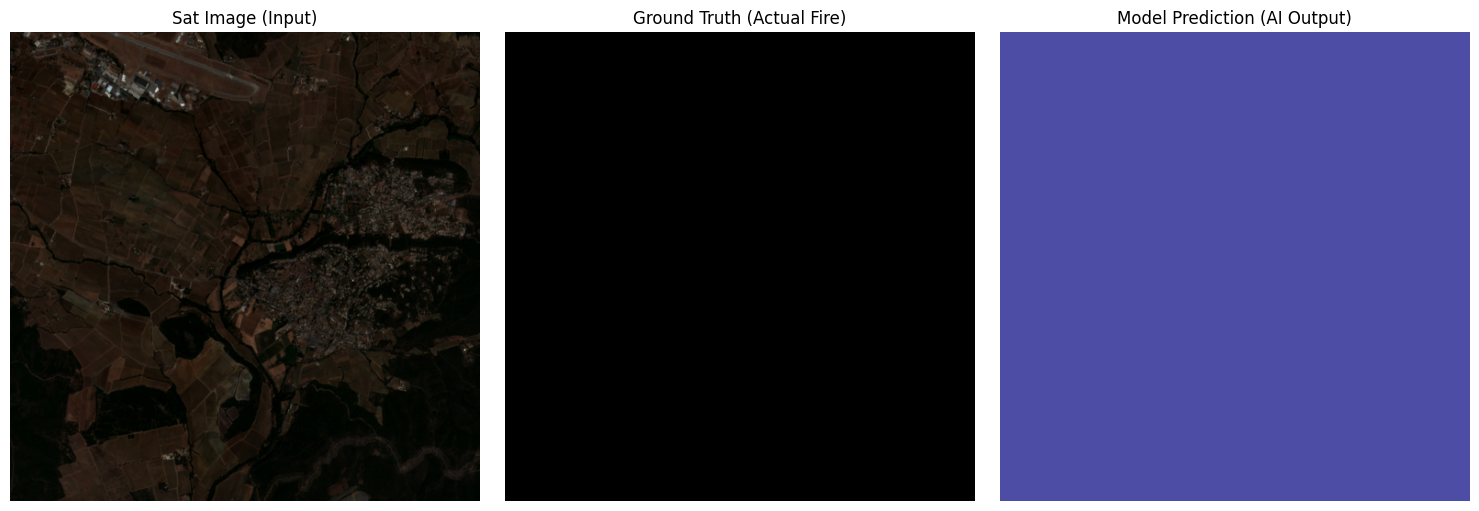

🧐 Inspecting Test Sample #66...


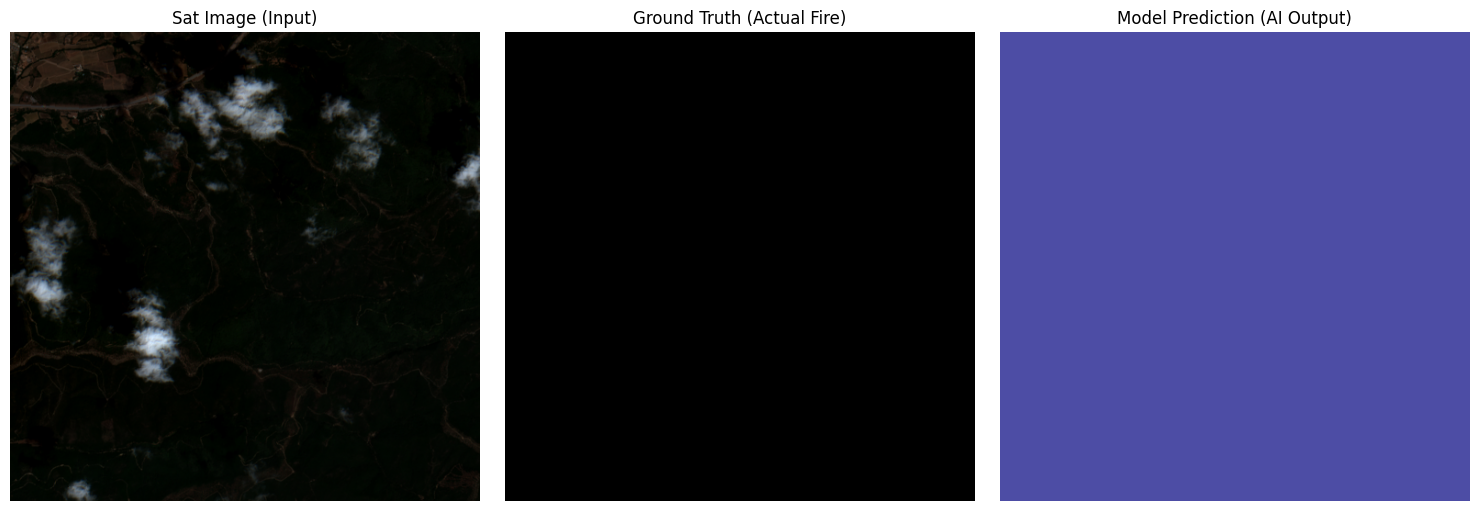

🧐 Inspecting Test Sample #5...


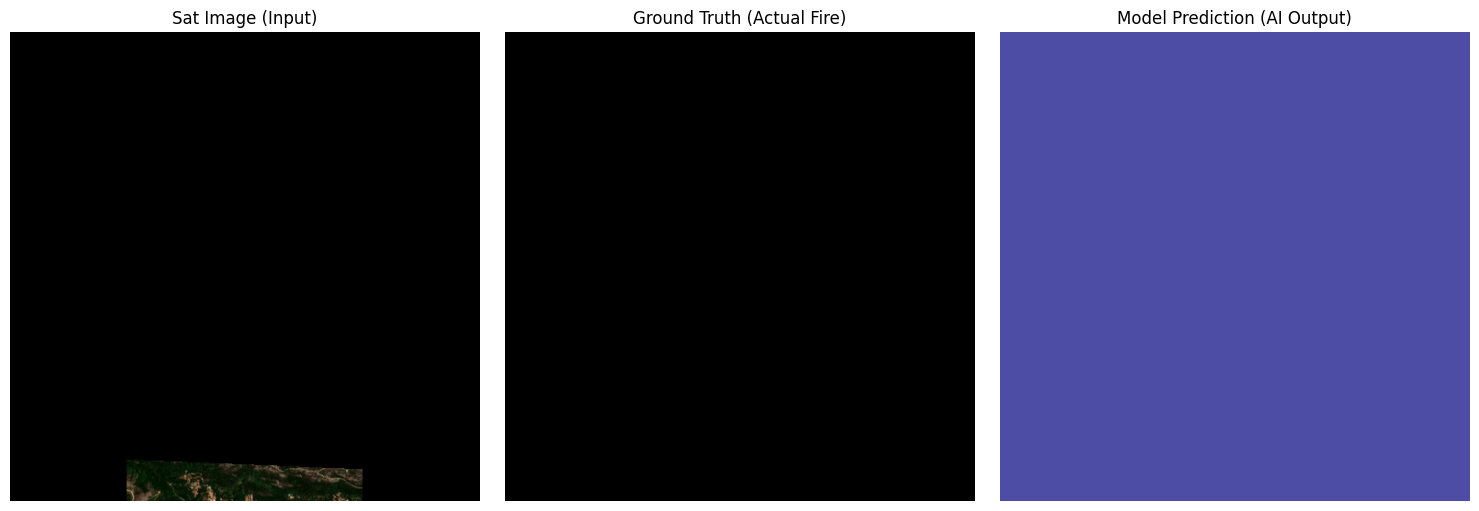

In [16]:
# --- Visual Test & Inspection Cell ---
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

# 1. Define Test Set (Using Validation set for Baseline Phase)
test_ds = val_ds

def visualize_prediction(dataset, model, index=None):
    """
    Visualizes: Input Image | Ground Truth Mask | Predicted Mask
    """
    # Pick a random image if no index provided
    if index is None:
        index = random.randint(0, len(dataset)-1)

    print(f"🧐 Inspecting Test Sample #{index}...")

    # Load Data
    sample = dataset[index]
    image = sample['pixel_values']
    label = sample['labels']

    # Run Inference
    model.eval()
    model.to(Config.DEVICE)
    with torch.no_grad():
        # Add batch dimension (C, H, W) -> (1, C, H, W)
        input_tensor = image.unsqueeze(0).to(Config.DEVICE)
        outputs = model(pixel_values=input_tensor)

        # Upsample logits to original size (SegFormer output is 1/4th size)
        logits = nn.functional.interpolate(
            outputs.logits,
            size=label.shape[-2:], # Match Ground Truth H,W
            mode="bilinear",
            align_corners=False
        )

        # Get Prediction (Argmax)
        pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Prepare for Plotting
    # Image: (C, H, W) -> (H, W, C) & Denormalize for display
    img_display = image.permute(1, 2, 0).numpy()

    # Normalize image to 0-1 range for matplotlib if it isn't already
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Original Image
    axes[0].imshow(img_display)
    axes[0].set_title("Sat Image (Input)")
    axes[0].axis("off")

    # 2. Ground Truth
    axes[1].imshow(label, cmap="gray", interpolation="nearest")
    axes[1].set_title("Ground Truth (Actual Fire)")
    axes[1].axis("off")

    # 3. Prediction
    axes[2].imshow(pred_mask, cmap="jet", alpha=0.7, interpolation="nearest")
    axes[2].set_title("Model Prediction (AI Output)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# --- Run Visualization ---
# Run this multiple times to see different "Test" examples
for i in range(3):
    visualize_prediction(test_ds, model)

In [17]:
# --- Save Model to Google Drive ---
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
# This uses your existing Config class to find the local model
local_model_path = f"./models/{Config.EXPERIMENT_NAME}"

# Define where you want it on Drive
# It will create a folder "Satellite_Project_Models" if it doesn't exist
drive_dest_path = f"/content/drive/MyDrive/Satellite_Project_Models/{Config.EXPERIMENT_NAME}"

# 3. Copy the Model
if os.path.exists(local_model_path):
    print(f"\n🚀 Copying model from {local_model_path} to {drive_dest_path}...")

    # If a version already exists on Drive, remove it to ensure we save the latest
    if os.path.exists(drive_dest_path):
        print("   (Overwriting existing version on Drive...)")
        shutil.rmtree(drive_dest_path)

    # Copy the directory
    shutil.copytree(local_model_path, drive_dest_path)
    print("✅ Success! Model safely saved to Google Drive.")
else:
    print(f"❌ Error: Could not find local model at {local_model_path}. Did the training finish?")

Mounted at /content/drive

🚀 Copying model from ./models/segformer_b0_zenodo_burned_area to /content/drive/MyDrive/Satellite_Project_Models/segformer_b0_zenodo_burned_area...
✅ Success! Model safely saved to Google Drive.
